<P642-  Patient's Condition Classification Using Drug Reviews>

Business Objective:

This is a sample dataset which consists of 161297 drug name, condition reviews and ratings from different patients and our goal is to examine how patients are feeling using the drugs their positive and negative experiences so that we can recommend him a suitable drug. By analyzing the reviews, we can understand the drug effectiveness and its side effects. 

The dataset provides patient reviews on specific drugs along with related conditions and a 10 star patient rating reflecting overall patient satisfaction.
So in this dataset, we can see many patients conditions but we will focus only on the below, classify the below conditions from the patients reviews 

a. Depression

c. High Blood Pressure

d. Diabetes, Type 2


In [1]:
##importing the required libraries

##Data Handling libraries
import pandas as pd  ##importing the pandas library to work with files and data manipulation 
import numpy as np ##importing the numpy library for mathematical manipulations

In [2]:
##Loading the dataset 

df = pd.read_excel(r'C:\Users\arunr\Desktop\Data Science\Project\Dataset and basic files\drugsCom_raw.xlsx')

df.head() ##checking the accuracy of the file by loading the first few rows

,Unnamed: 0,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37


In [3]:
##Preprocessing of data

##Checking the shape of the dataset 
print("Dataset Shape:", df.shape) ##Using the .shape function to get the dimension of the dataset 

##Checking for milling values 
print("\nMissing Values:\n", df.isnull().sum()) ##Using the isnull function to get the total number of null values in the dataset 

##Removing duplicates 
df.drop_duplicates(inplace=True) ##Using the drop_duplicates function to drop all duplicates in the dataset 
print("\nDuplicates removed successfully")

Dataset Shape: (161297, 7)

Missing Values:
 Unnamed: 0       0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

Duplicates removed successfully


In [4]:
##From the above oytput, we can conculde the below:
    #1. The dataset consists of 161297 rows and 7 columns 
    #2. There are 899 missing values in the column condition which is a categorical column and we don't need to handle the missing values 
    #3. All duplicates are successfully removed from the dataset 

In [5]:
##We will now handle the missing values as they will take up the y value

df['condition'] = df['condition'].fillna("Unknown") ##Replacing all missing values with unknown

##Checking for milling values after replacing them with unknown
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Unnamed: 0     0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
dtype: int64


In [6]:
##From the above output, we can confirm that all missing values are handled by replacing them with Unknown 

In [16]:
##Filtering the required columns Depression, High Blood Pressure and Diabetes, Type 2

conditions = ["Depression", "High Blood Pressure", "Diabetes, Type 2"] ##Filtering the required criteria from the conditions column 

df_filtered = df[df['condition'].isin(conditions)] ##Storing the filtered data into the existing dataset based on conditions 
 
print(df['condition'].value_counts()) ##Printing the number of entries with the required conditions 

condition
Depression             9069
Diabetes, Type 2       2554
High Blood Pressure    2321
Name: count, dtype: int64


In [8]:
##From the above output, we can see that there are: 
    #1. 9069 entries in the Depression column 
    #2. 2554 entries in the Diabetes, Type 2  
    #3. 2321 entries in the High Blood Pressure column 

In [14]:
##Importing libraries to create visualizations 

import matplotlib.pyplot as plt ##Importing the matplotlib library to create visualizations
import seaborn as sns ##Importing the seaborn library to create advanced visualizations
from wordcloud import WordCloud ##Importing the wordcloud library to create a visualization with the positive words from the reviews 


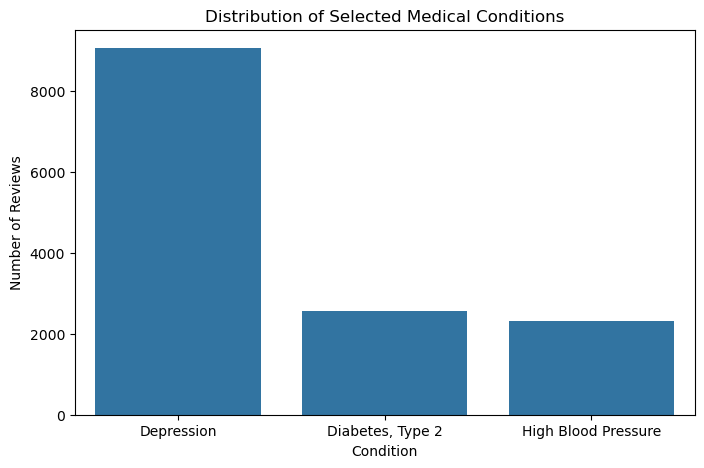

In [17]:
    ##Countplot to check the distribution of reviews for the filtered conditions 

plt.figure(figsize=(8,5)) ##determining the figure size

sns.countplot( ##Plotting the count plot
    x='condition',  ##Using the column condition from the dataset 
    data=df_filtered, ##Dataframe after filtering the conditions 
    order=df_filtered['condition'].value_counts().index ##Sorting the number of connditions 
)
 
plt.title("Distribution of Selected Medical Conditions") ##Naming the figure
plt.xlabel("Condition") ##Naming the x axis 
plt.ylabel("Number of Reviews") ##Naming the y axis

plt.show() ##Printing the graph 

In [ ]:
##The above graph shows:
    #The condition "Depression" has over 8000+ reviews 
    #The condition "Diabetes, Type 2" has over 3000+ reviews 
    #The condition "High Blood Pressure" has over 2000+ reviews 

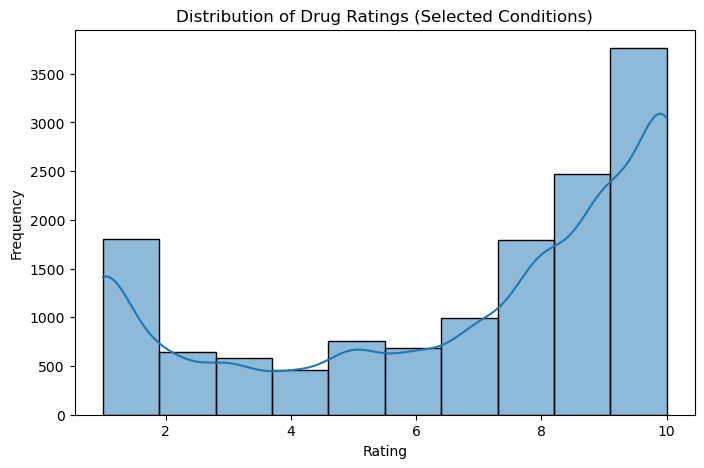

In [18]:
    ##Visualizing the patient satisfaction with a histogram 

plt.figure(figsize=(8,5)) ##Determining a figure size for the plot 

sns.histplot( ##Plotting a histogram 
    df_filtered['rating'], ##Using the column rating from the filtered dataframe 
    bins=10, ##Grouping 10 values 
    kde=True ##Adding a density line to the histogram 
)

plt.title("Distribution of Drug Ratings (Selected Conditions)") ##Naming the graph 
plt.xlabel("Rating") ##Naming the x axis 
plt.ylabel("Frequency") ##Naming the y axis 

plt.show() ##Printing the figure 

In [ ]:
##From the above Density plot, we can see that
    #Most reviews are positive and distributed between 7 and 10
    #There are very few negative ratings 

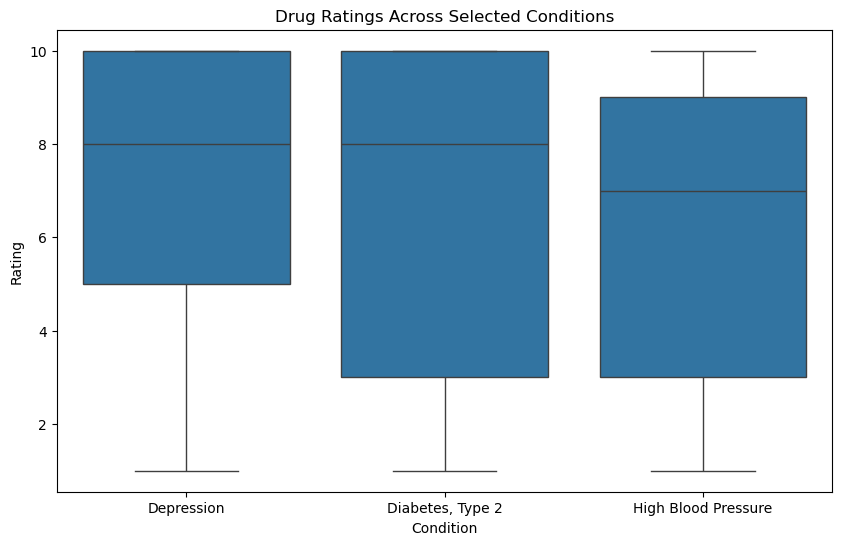

In [19]:
##Checking the variation in ratings across the filitered conditions using a boxplot 

plt.figure(figsize=(10,6)) ##Determining a figure size for the plot 

sns.boxplot( ##Creating a boxplot 
    x='condition', ##X takes the column condition
    y='rating', ##Y takes the column rating 
    data=df_filtered ##Using the filtered dataframe 
)

plt.title("Drug Ratings Across Selected Conditions") ##Naming the figure
plt.xlabel("Condition") ##Naming the x axis 
plt.ylabel("Rating") ##Naming the y axis 

plt.show() ##Printing the figure 

In [ ]:
##From the above boxplot, we can conclude the following:
    #The ratings for the condition "Depression" is above 5 to 10 with a median of 8. This indicates the reviews are high for this condition 
    #The ratings for the condition "Diabetes, Type 2" is between 3 and 10 with a median 8. This indicates the reviews are mixed. 
    #The ratings for the condition "High Blood Pressure" is between 3 to 9 with a median of 7, indicating the reviews are intermediate. 

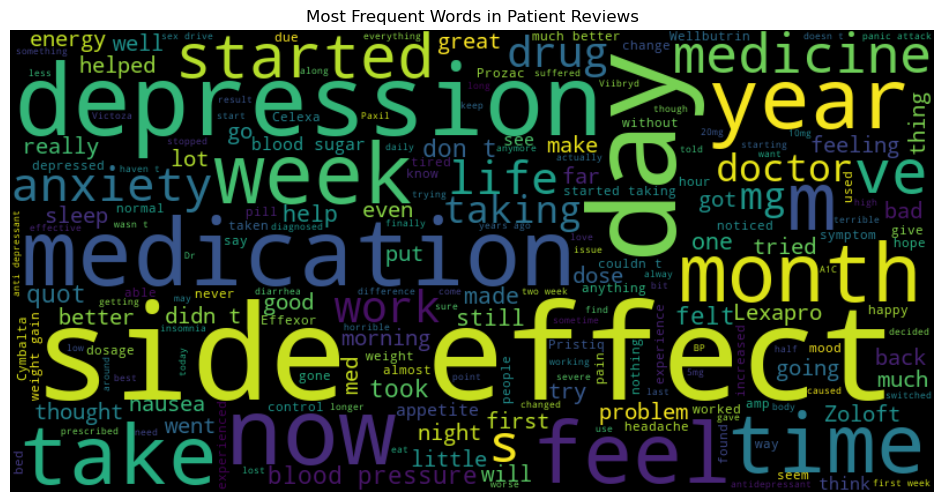

In [20]:
##Using a word cloud visual to highlight the most common and positive words used 

text = " ".join(df_filtered['review'].astype(str)) ##Converting each review into a large string 

wordcloud = WordCloud( ##creating a word cloud 
    width=800, ##Determining the width of the word cloud 
    height=400, ##Determining the height of the word cloud  
    background_color="black" ##Adding a background colour black  to the visual 
).generate(text) ##Generating the word could with the conditions 

plt.figure(figsize=(12,6)) ##Plotting a new canvas 
plt.imshow(wordcloud, interpolation="bilinear") ##Displaying the wordcloud in the canvas 
plt.axis("off") ##Removing the x and y axis as it's not needed for a word cloud 

plt.title("Most Frequent Words in Patient Reviews") ##Naming the graph 

plt.show() ##Printing the plotted word cloud 

In [21]:
##Libraries for Preprocessing data to create models 

##EDA
from sklearn.model_selection import train_test_split ##Importing this function to split data into subsets for testing and training purposes
from sklearn.preprocessing import LabelEncoder ##importing this function to convert categorical labels to numeric 

##TF IDF
from sklearn.feature_extraction.text import TfidfVectorizer ##Importing the TfidfVectorizer function to convert text to numbers to build models

## Libraries needed for NLP preprocessing
import re ##importing the regular expression function for text cleaning 
import nltk ##importing the Main Natural Language Toolkit library
from nltk.corpus import stopwords ##Importing this function to remove common words
from nltk.stem import WordNetLemmatizer ##Importing this library to reduce vocabulary size

##Pipeline and models 
from sklearn.pipeline import Pipeline ##Importing the pipeline library to perform Text cleaning, TF-IDF conversion and Train the model
from sklearn.linear_model import LogisticRegression ##Using this library to create a logistic regression model to predict categories
from sklearn.naive_bayes import MultinomialNB ##importing this library to create the Naive Bayes model 
from sklearn.svm import LinearSVC ##Importing this library to craete the Linear SVM model 
from sklearn.ensemble import RandomForestClassifier ##Importing this library to create the random forest classifier 

##Hyperparameter tuning and evaluation 
from sklearn.model_selection import GridSearchCV ##Used for hyperparameter tuning of the models 
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score ##Evaluting the models 

##Saving the best model 
import joblib ##Importing this library to save and load the trained model 

In [25]:
##We will now proceed with encoding for building the model 
label_encoder = LabelEncoder() ##calling the label encoder function to convert categorical labels into numeric 

##Converting the categorical labels to numeric and storing them in a new column 
df_filtered['condition_encoded'] = label_encoder.fit_transform(df_filtered['condition']) 

print(label_encoder.classes_) ##prinying the encoded class

['Depression' 'Diabetes, Type 2' 'High Blood Pressure']


In [26]:
##The above output confirms the categorical labels are encoded into numeric 

In [27]:
##We will now split the dataset into subsets for testing and training purposes 


X = df_filtered['review'] ##Features which the data learns from, hence we take review as the feature as it contains the patients reviews 
y = df_filtered['condition_encoded'] ##Target column is the conditions after encoded as we will predict this using the features 


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Here we are splitting the dataset into sub datasets with 20% data for testing and 80% data for training. Where X is the input features which is the
    #tfidf vectors and y is the target labels which are encoded. 
    #We will use the standard stratify seed value of 42 to keep the keep class distribution equal

In [28]:
##We will now build the model using the pipeline method which will help retain the structure and makes the model easy to access.

##The pipeline method is used here as we can include all major steps to build the NLP model in one pleace, example cleaning, vectorizing and modelling
    #We will add all the models within the pipeline 

nltk.download('stopwords') ##Downloading the common words 
nltk.download('wordnet')##Downloading the function for lemmatization or changing the words to root form 

pipelines = { ##Creating a pipleline workflow for all the models 
    
    "Logistic Regression": Pipeline([  ##creating a pipeline for the logistic regression model 
         ('tfidf', TfidfVectorizer(
                lowercase=True,
                stop_words='english',
                token_pattern=r'[a-zA-Z]+',
                max_df=0.9,
                min_df=5,
                ngram_range=(1,2)
        )),   ##Using unigram and bigram words as features 
        ('classifier', LogisticRegression(max_iter=1000)) ##Creating the logistic regression model 
    ]),
    
    "Naive Bayes": Pipeline([ ##creating a pipeline for the Naive Bayes model 
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            stop_words='english',
            token_pattern=r'[a-zA-Z]+',
            max_df=0.9,
            min_df=5,
            ngram_range=(1,2)
        )), 
        ('classifier', MultinomialNB()) ##Creating the Naive Bayes Model  
    ]),
    
    "Linear SVM": Pipeline([ ##creating a pipeline for a logistic regression model 
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            stop_words='english',
            token_pattern=r'[a-zA-Z]+',
            max_df=0.9,
            min_df=5,
            ngram_range=(1,2)
        )), 
        ('classifier', LinearSVC()) ##Creating the Linear SVM model 
    ]),

      "Random Forest": Pipeline([ ##creating a pipeline for a logistic regression model 
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            stop_words='english',
            token_pattern=r'[a-zA-Z]+',
            max_df=0.9,
            min_df=5,
            ngram_range=(1,2)
        )),  
         ('classifier', RandomForestClassifier(n_estimators=100, random_state=42)) ##Creating the Random Forest 

    ]),
}


##The Text preprocessing is defined separately outside the pipeline mode and called here. This is a recommended prectice because 
    #It is reusable
    #It is automatically applied during training and prediction
    #It avoids data leakage

##We are using the ngram_range=(1,2) which captures one and two word phrases. It makes more meaning without making the model too complex.

##We will run the model 1000 times to ensure the Model properly learns and provides better stability 

##We use class_weight='Balanced' to handle class imablance as this automatically gives more importance to minority class 
    #and prevents bias toward majority class

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\arunr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\arunr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [29]:
##Training and evaluating each model 

for name, pipeline in pipelines.items(): ##Using the For Loop to iterate through each model 
    pipeline.fit(X_train, y_train) ##Training the model with the training data set 
    y_pred = pipeline.predict(X_test) ##Making predictions for the target with the x test values 
    
    print(f"{name} Accuracy:", accuracy_score(y_test, y_pred)) ##Calculating and printing the accuracy of the models based on the predictions made

    print("\nClassification Report:\n") 
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))#Calculating and printing the classification report for each model

Logistic Regression Accuracy: 0.9476514879885264

Classification Report:

                     precision    recall  f1-score   support

         Depression       0.94      0.99      0.96      1814
   Diabetes, Type 2       0.97      0.91      0.94       511
High Blood Pressure       0.96      0.82      0.88       464

           accuracy                           0.95      2789
          macro avg       0.96      0.91      0.93      2789
       weighted avg       0.95      0.95      0.95      2789

Naive Bayes Accuracy: 0.927572606669057

Classification Report:

                     precision    recall  f1-score   support

         Depression       0.91      1.00      0.95      1814
   Diabetes, Type 2       0.99      0.87      0.92       511
High Blood Pressure       0.97      0.72      0.83       464

           accuracy                           0.93      2789
          macro avg       0.95      0.86      0.90      2789
       weighted avg       0.93      0.93      0.92      2789

L

In [30]:
##From the above output, we observe the following:
    #There are 4 models built.
    #The Logistic Regression model has an accuracy of 94%
    #The Naive Baye's model has an accuracy of 91%
    #The Linear SVM model has an accuracy of 96%
    #The Random Forest model has an accuracy of 95%

##The recall value is almost identical for all the models.
##The Precision and F1 score are similar to each other

In [31]:
##We will now proceed with Hyperparameter tuning to find the best models 

param_grids = {
    "Logistic Regression": { ##Tuning the Logistic regression model
        'classifier__C': [0.1, 1, 10]  ##Defining the regularization strength  
    },
    
    "Naive Bayes": { ##Tuning the Naive Bayes model
        'classifier__alpha': [0.1, 0.5, 1] ##Defining the smopothing parameter 
    },
    
    "Linear SVM": { ##Tuning the Linear SVM model
        'classifier__C': [0.1, 1, 10]  ##Defining the regularization strength  
    },
    
    "Random Forest": { ##Tuning the Random Forest model
        'classifier__n_estimators': [100, 200], ##Estimating the number of trees in the forest 
        'classifier__max_depth': [None, 10, 20] ##Controlling overfitting
    }
}

In [32]:
##Evaluation of the tuned model 

results = [] ##Creating an empty list to store the results 

for name in pipelines.keys(): ##using the for loop to iterate through all the models 
    
    print("\n" + "="*60)
    print(f"Tuning {name}") ##Printing the name of the model 
    print("="*60)

    ##Using grid search to search through all parameter combinations for the pipeline and find the best one using cross-validation
    grid = GridSearchCV( 
        pipelines[name], ##Model within the pipeline 
        param_grids[name], ##Passing the parameters for hypertuning 
        cv=3, ##Passing the 3 fold cross validation 
        scoring='accuracy', ##Choosing the best model based on accuracy 
        n_jobs=-1 ##Ideal for faster execution 
    )
    
    grid.fit(X_train, y_train) ##Training the tuned models with the training data set
    
    best_model = grid.best_estimator_
    y_pred_best = best_model.predict(X_test) ##Making predictions 
    
    ##Calculating the evaluation metrics
    accuracy = accuracy_score(y_test, y_pred_best)
    precision = precision_score(y_test, y_pred_best, average='weighted')
    recall = recall_score(y_test, y_pred_best, average='weighted')
    f1 = f1_score(y_test, y_pred_best, average='weighted')

    ##Printing the parameters and evaluation metrics 
    print("Best Parameters:", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    print("Test Accuracy:", accuracy)

    ##Storing the results in the list with the appropriate column names 
    results.append({
        "Model": name,
        "Best CV Score": grid.best_score_,
        "Test Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })


Tuning Logistic Regression
Best Parameters: {'classifier__C': 10}
Best CV Score: 0.9588523630863383
Test Accuracy: 0.9627106489781284

Tuning Naive Bayes
Best Parameters: {'classifier__alpha': 0.1}
Best CV Score: 0.9514120265873219
Test Accuracy: 0.9562567228397275

Tuning Linear SVM
Best Parameters: {'classifier__C': 1}
Best CV Score: 0.9602868501662636
Test Accuracy: 0.9630692004302618

Tuning Random Forest
Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Best CV Score: 0.9438812888354743
Test Accuracy: 0.9555396199354608


In [33]:
##After Hyperparameter tuning the accuracy for each model has changed as below:
    #Logistic regression model: 94% to 96.30% - Shows a slight improvement in the model 
    #Naive Bayes model: 91% to 95.73% - Shows a significant increase in the model's performance 
    #Linear SVM model: 96.34% to 96.34 - There is no change in performance  
    #Random Forest: 95% to 95.41% - There is mininal improvement in the model's performance 

In [34]:
##Comparison of the models 

comparison_df = pd.DataFrame(results) ##Creating a dataframe to store the comparison results 

comparison_df = comparison_df.sort_values( ##creating a dataframe
    by="Test Accuracy",  ##Sorting the rows with respect to the accuracy results 
    ascending=False ##Sorting the models in ascending order 
).reset_index(drop=True) ##Adding index to the dataframe 

comparison_df ##printing the dataframe 

,Model,Best CV Score,Test Accuracy,Precision,Recall,F1 Score
0,Linear SVM,0.960287,0.963069,0.962907,0.963069,0.962704
1,Logistic Regression,0.958852,0.962711,0.962581,0.962711,0.962295
2,Naive Bayes,0.951412,0.956257,0.956026,0.956257,0.955731
3,Random Forest,0.943881,0.955540,0.955911,0.955540,0.954783


In [35]:
##Choosing the best model 

best_model_name = comparison_df.iloc[0]["Model"] ##Identifying the model that's at the 0th position using the iloc function 
print("Best Performing Model:", best_model_name) ##Printing the results 

Best Performing Model: Linear SVM


In [36]:
##We can conculde that the best performing model is the Linear SVM. 

[[1797    4   13]
 [  28  476    7]
 [  68    4  392]]


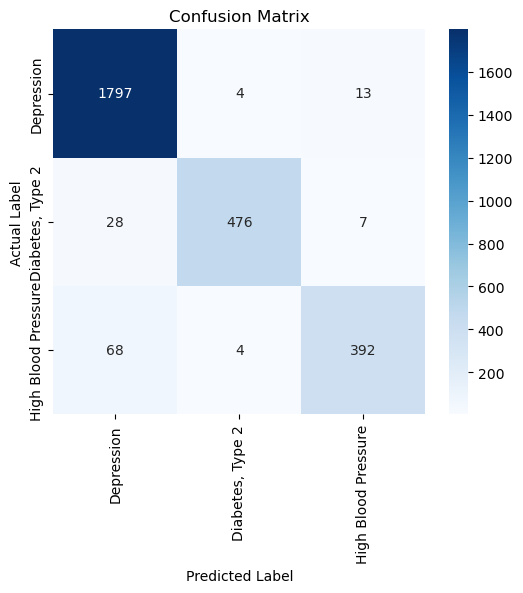

In [37]:
##Confusion matrix for the best performing model 

import seaborn as sns ##importing the seaborn library to create the heatmap which is an advanced visual 
import matplotlib.pyplot as plt ##importing this library to create a visual 

cm = confusion_matrix(y_test, y_pred) ##Storing the confusion matrix 

print(cm)

plt.figure(figsize=(6,5)) ##Determing the figure size 
sns.heatmap( ##Creating a heatmap 
    cm,
    annot=True, ##Displaying the actual numbers inside each box
    fmt='d', ##Formating the numbers as integers 
    cmap='Blues', ##Setting the colour theme to blue 
    xticklabels=label_encoder.classes_, ##X axis will hold the predicted labels
    yticklabels=label_encoder.classes_ ##Y axis will hold the actual labels 
) 

plt.xlabel("Predicted Label") ##Naming the x axis 
plt.ylabel("Actual Label") ##naming the y Axis
plt.title("Confusion Matrix") ##Adding a title to the figure
plt.show() ##Printing the figure 

In [38]:
##From the above confusion matrix, we observe that The confusion matrix shows strong diagonal dominance,
    #indicating that the correct predictions are higher then the miscalculated ones, making the model highly accurate 

In [39]:
##We will now save the pipeline model 

# Get best trained grid model
best_pipeline = grid.best_estimator_

# Create a package dictionary
model_package = {
    "model": best_pipeline,
    "label_encoder": label_encoder
}

# Save everything into ONE pickle file
joblib.dump(model_package, "drug_condition_pipeline.pkl")

print("✅ Model and encoder saved successfully in single pickle file!")
##Using the joblib.dump library, the pipeline model that was created is saved as a Pickle file in the name condition_classification_model.pkl 

##Since the text was converted to numbers earlier, we will now encode them back to text for a human friendly output

✅ Model and encoder saved successfully in single pickle file!


In [40]:
##The above shows the pipeline model has been successfully saved as a Pickle file. 